In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import cmocean
#import gsw

In [3]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [4]:
extent = 3
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))

In [27]:
Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values[:,::100]
Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','lon','lat']).values[:,::100]

Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values[:,::100]
Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','lon','lat']).values[:,::100]

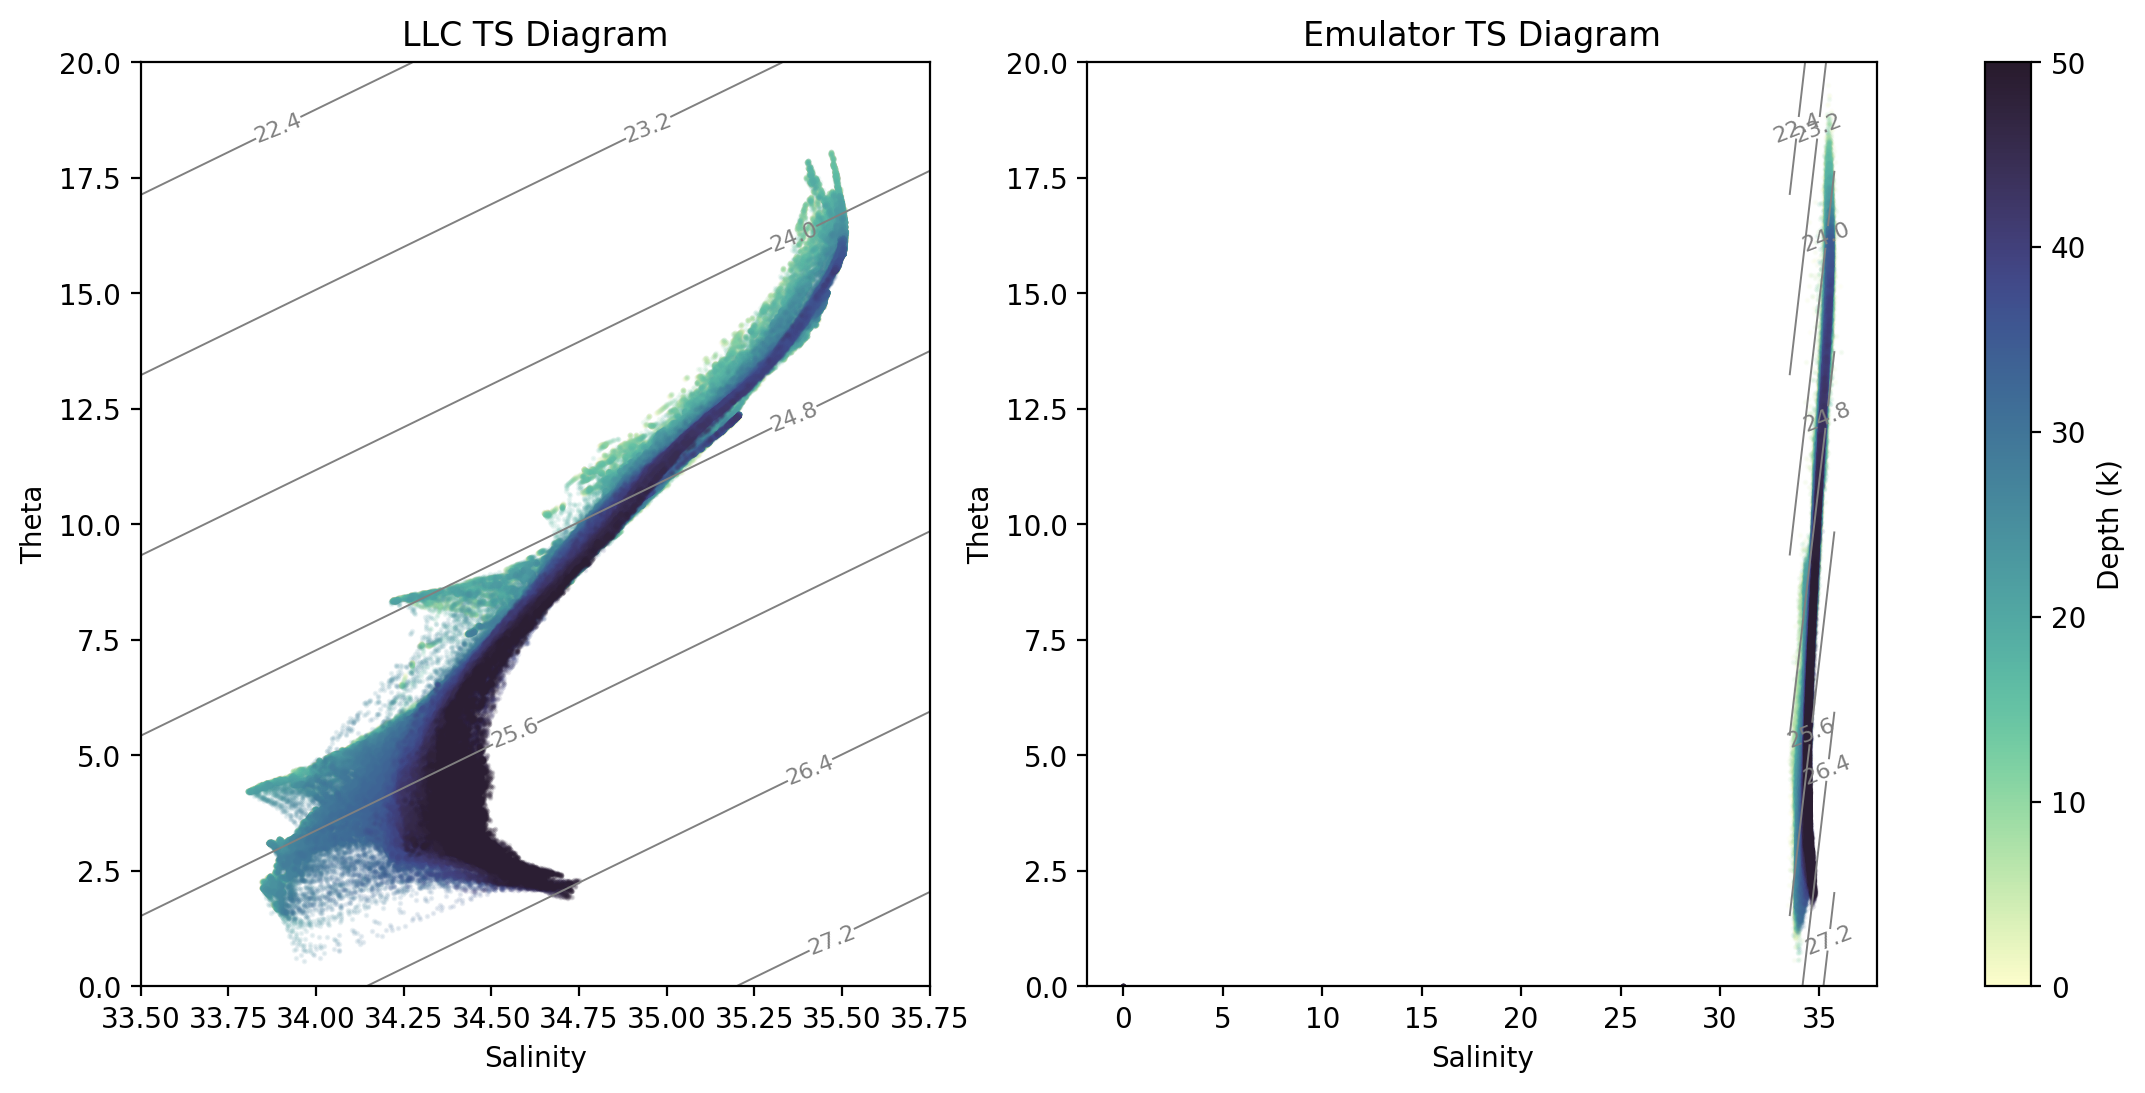

In [28]:
# generate TS grid
T = np.linspace(0,20,100)
S = np.linspace(33.5,35.75,100)
Sg, Tg = np.meshgrid(S,T)

# compute potential density - 1000 (linear EOS approximation)
rho0 = 1025.0
alpha = 2e-4
beta = 7.4e-4
T_ref = 10.0
S_ref = 35.0

sigma = rho0 * (1 - alpha * (Tg - T_ref) + beta * (Sg - S_ref)) - 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# LLC TS diagram
cs1 = ax1.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax1.clabel(cs1, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_llc)):
    ax1.scatter(Salt_hist_llc[k], Theta_hist_llc[k], 
                c=[cmocean.cm.deep(k/len(Salt_hist_llc))], s=1, alpha=0.1)
ax1.set_xlabel("Salinity")
ax1.set_ylabel("Theta")
ax1.set_title("LLC TS Diagram")

# Emulator TS diagram
cs2 = ax2.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax2.clabel(cs2, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_emulator)):
    ax2.scatter(Salt_hist_emulator[k], Theta_hist_emulator[k], 
                c=[cmocean.cm.deep(k/len(Salt_hist_emulator))], s=1, alpha=0.1)
ax2.set_xlabel("Salinity")
ax2.set_ylabel("Theta")
ax2.set_title("Emulator TS Diagram")

# Shared depth colorbar
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.deep, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, ax=[ax1, ax2], label='Depth (k)')

#plt.tight_layout()
plt.show()

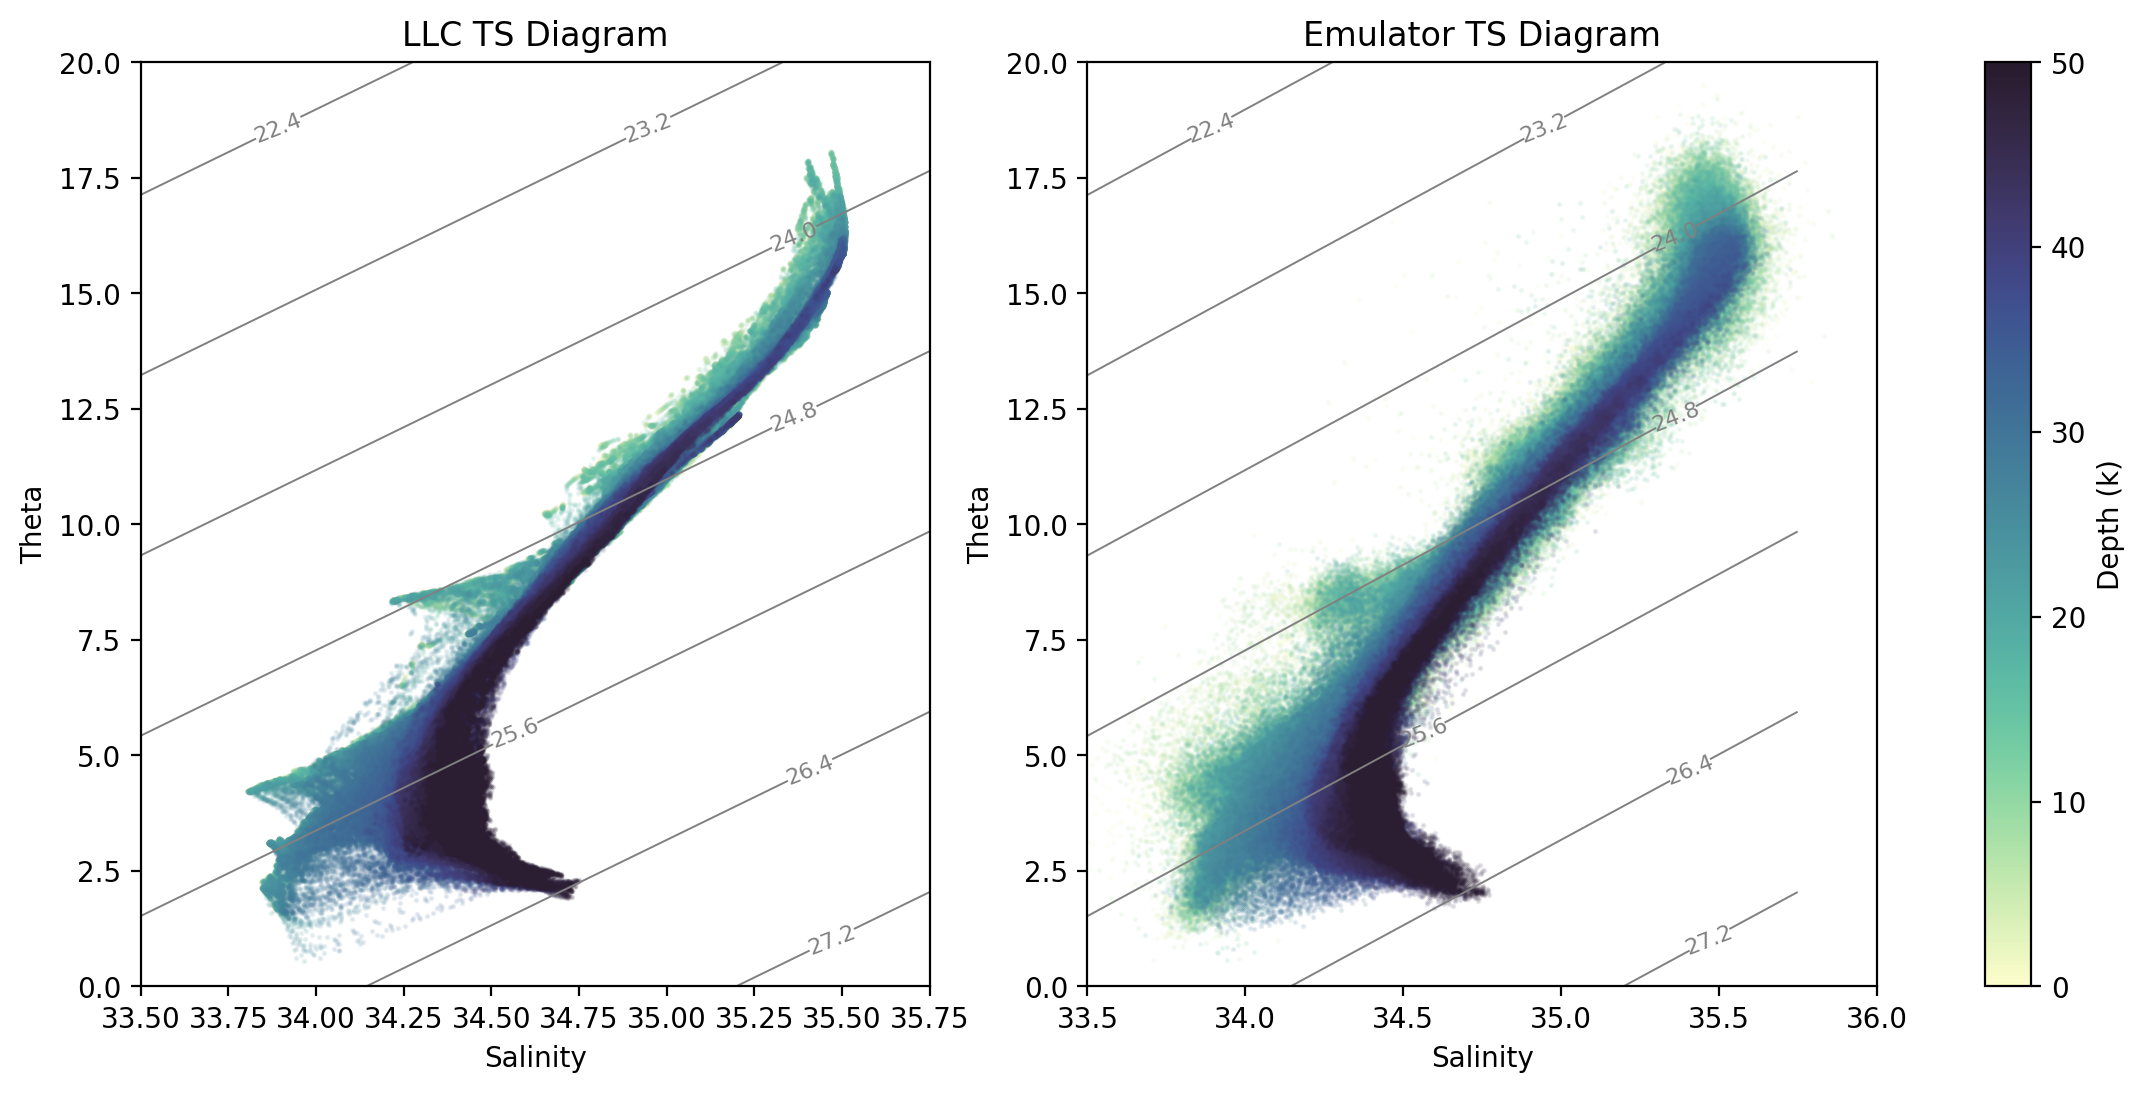

In [ ]:
# generate TS grid
T = np.linspace(0,20,100)
S = np.linspace(33.5,35.75,100)
Sg, Tg = np.meshgrid(S,T)

# compute potential density - 1000 (linear EOS approximation)
rho0 = 1025.0
alpha = 2e-4
beta = 7.4e-4
T_ref = 10.0
S_ref = 35.0

sigma = rho0 * (1 - alpha * (Tg - T_ref) + beta * (Sg - S_ref)) - 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

# LLC TS diagram
cs1 = ax1.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax1.clabel(cs1, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_llc)):
    ax1.scatter(Salt_hist_llc[k], Theta_hist_llc[k], 
                c=[cmocean.cm.deep(k/len(Salt_hist_llc))], s=1, alpha=0.1)
ax1.set_xlabel("Salinity")
ax1.set_ylabel("Theta")
ax1.set_title("LLC TS Diagram")

# Emulator TS diagram
cs2 = ax2.contour(Sg, Tg, sigma, colors='grey', linewidths=0.7)
ax2.clabel(cs2, inline=1, fontsize=8, fmt="%.1f")
for k in range(len(Salt_hist_emulator)):
    ax2.scatter(Salt_hist_emulator[k], Theta_hist_emulator[k], 
                c=[cmocean.cm.deep(k/len(Salt_hist_emulator))], s=1, alpha=0.1)
ax2.set_xlabel("Salinity")
ax2.set_ylabel("Theta")
ax2.set_title("Emulator TS Diagram")
ax2.set_xlim(33.5,36)

# Shared depth colorbar
sm = plt.cm.ScalarMappable(cmap=cmocean.cm.deep, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, ax=[ax1, ax2], label='Depth (k)')

#plt.tight_layout()
plt.show()